# Baseline Model: Linear Regression

**Purpose:** Establish baseline performance for electricity demand prediction using simple linear regression.

**Features Used:**
- Weather: Temperature, Humidity, Dew Point, Wind Speed, Pressure
- Temporal: Hour, DayOfWeek, Month, IsWeekend

**Target:** Ontario Demand (MW)

**Expected Performance:** RMSE ~1,500-2,000 MW (baseline for comparison with advanced models)

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load the final merged dataset
data_path = "../../../02_Datasets/processed/final_merged_ieso_weather.csv"
df = pd.read_csv(data_path, parse_dates=['DateTime'])

print("Dataset loaded successfully!")
print(f"Records: {len(df):,}")
print(f"Date range: {df['DateTime'].min()} to {df['DateTime'].max()}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nFirst 3 rows:")
df.head(3)

Dataset loaded successfully!
Records: 109,056
Date range: 2013-06-01 00:00:00 to 2025-11-09 00:00:00

Columns (17):
['DateTime', 'Date', 'Hour', 'Year', 'Month', 'DayOfWeek', 'DayOfYear', 'IsWeekend', 'Market Demand', 'Ontario Demand', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Dir (10s deg)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)']

First 3 rows:


,DateTime,Date,Hour,Year,Month,DayOfWeek,DayOfYear,IsWeekend,Market Demand,Ontario Demand,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Wind Dir (10s deg),Wind Spd (km/h),Visibility (km),Stn Press (kPa)
0,2013-06-01 00:00:00,2013-06-01,1,2013,6,5,152,1,15908,13731,17.8,16.0,89.0,0.0,21.0,24.1,98.66
1,2013-06-01 01:00:00,2013-06-01,2,2013,6,5,152,1,15126,13143,17.8,16.0,89.0,0.0,21.0,24.1,98.66
2,2013-06-01 02:00:00,2013-06-01,3,2013,6,5,152,1,14652,12778,17.8,16.0,89.0,0.0,21.0,24.1,98.66


In [4]:
# Select features for modeling
feature_columns = [
    'Hour', 'DayOfWeek', 'Month', 'IsWeekend',  # Temporal features
    'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)',  # Weather features
    'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)'
]

target_column = 'Ontario Demand'

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Features (X):")
print(f"  Shape: {X.shape}")
print(f"  Columns: {X.columns.tolist()}")

print(f"\nTarget (y):")
print(f"  Shape: {y.shape}")
print(f"  Range: {y.min()} - {y.max()} MW")
print(f"  Mean: {y.mean():.1f} MW")

print(f"\nChecking for missing values:")
print(f"  Features: {X.isnull().sum().sum()}")
print(f"  Target: {y.isnull().sum()}")

Features (X):
  Shape: (109056, 10)
  Columns: ['Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)']

Target (y):
  Shape: (109056,)
  Range: 9831 - 24927 MW
  Mean: 15636.0 MW

Checking for missing values:
  Features: 0
  Target: 0


In [5]:
# Time-based split (no shuffling - respects temporal order)
# Training: 2013-2022 (70%)
# Validation: 2023 (9%) 
# Test: 2024-2025 (21%)

train_end = '2022-12-31 23:00:00'
val_end = '2023-12-31 23:00:00'

# Create splits based on datetime
train_mask = df['DateTime'] <= train_end
val_mask = (df['DateTime'] > train_end) & (df['DateTime'] <= val_end)
test_mask = df['DateTime'] > val_end

# Split features and target
X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("Data Split Summary:")
print("="*70)
print(f"Training Set:")
print(f"  Records: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Date range: {df[train_mask]['DateTime'].min()} to {df[train_mask]['DateTime'].max()}")

print(f"\nValidation Set:")
print(f"  Records: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Date range: {df[val_mask]['DateTime'].min()} to {df[val_mask]['DateTime'].max()}")

print(f"\nTest Set:")
print(f"  Records: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Date range: {df[test_mask]['DateTime'].min()} to {df[test_mask]['DateTime'].max()}")

Data Split Summary:
Training Set:
  Records: 84,024 (77.0%)
  Date range: 2013-06-01 00:00:00 to 2022-12-31 23:00:00

Validation Set:
  Records: 8,760 (8.0%)
  Date range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00

Test Set:
  Records: 16,272 (14.9%)
  Date range: 2024-01-01 00:00:00 to 2025-11-09 00:00:00


In [6]:
# Train linear regression model
print("Training Linear Regression model...")
print("-" * 70)

model = LinearRegression()
model.fit(X_train, y_train)

print("✓ Model trained successfully!")

# Make predictions on all sets
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Calculate metrics for each set
def calculate_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{set_name} Performance:")
    print(f"  RMSE: {rmse:.2f} MW")
    print(f"  MAE:  {mae:.2f} MW")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

# Evaluate on all sets
train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")
val_metrics = calculate_metrics(y_val, y_val_pred, "Validation Set")
test_metrics = calculate_metrics(y_test, y_test_pred, "Test Set")

print("\n" + "="*70)
print("Baseline Linear Regression Results Summary:")
print(f"  Test RMSE: {test_metrics['RMSE']:.2f} MW (this is our baseline to beat!)")

Training Linear Regression model...
----------------------------------------------------------------------
✓ Model trained successfully!

Training Set Performance:
  RMSE: 1977.14 MW
  MAE:  1567.61 MW
  R²:   0.2989
  MAPE: 10.22%

Validation Set Performance:
  RMSE: 1841.17 MW
  MAE:  1465.63 MW
  R²:   0.2644
  MAPE: 9.32%

Test Set Performance:
  RMSE: 2215.79 MW
  MAE:  1707.77 MW
  R²:   0.1509
  MAPE: 10.11%

Baseline Linear Regression Results Summary:
  Test RMSE: 2215.79 MW (this is our baseline to beat!)


Target folder: C:\Users\nabee\OneDrive - University of Toronto\ECE1513H ML Project\04_Presentation
Exists: True

✓ Saved to OneDrive: C:\Users\nabee\OneDrive - University of Toronto\ECE1513H ML Project\04_Presentation\baseline_lr_performance.png


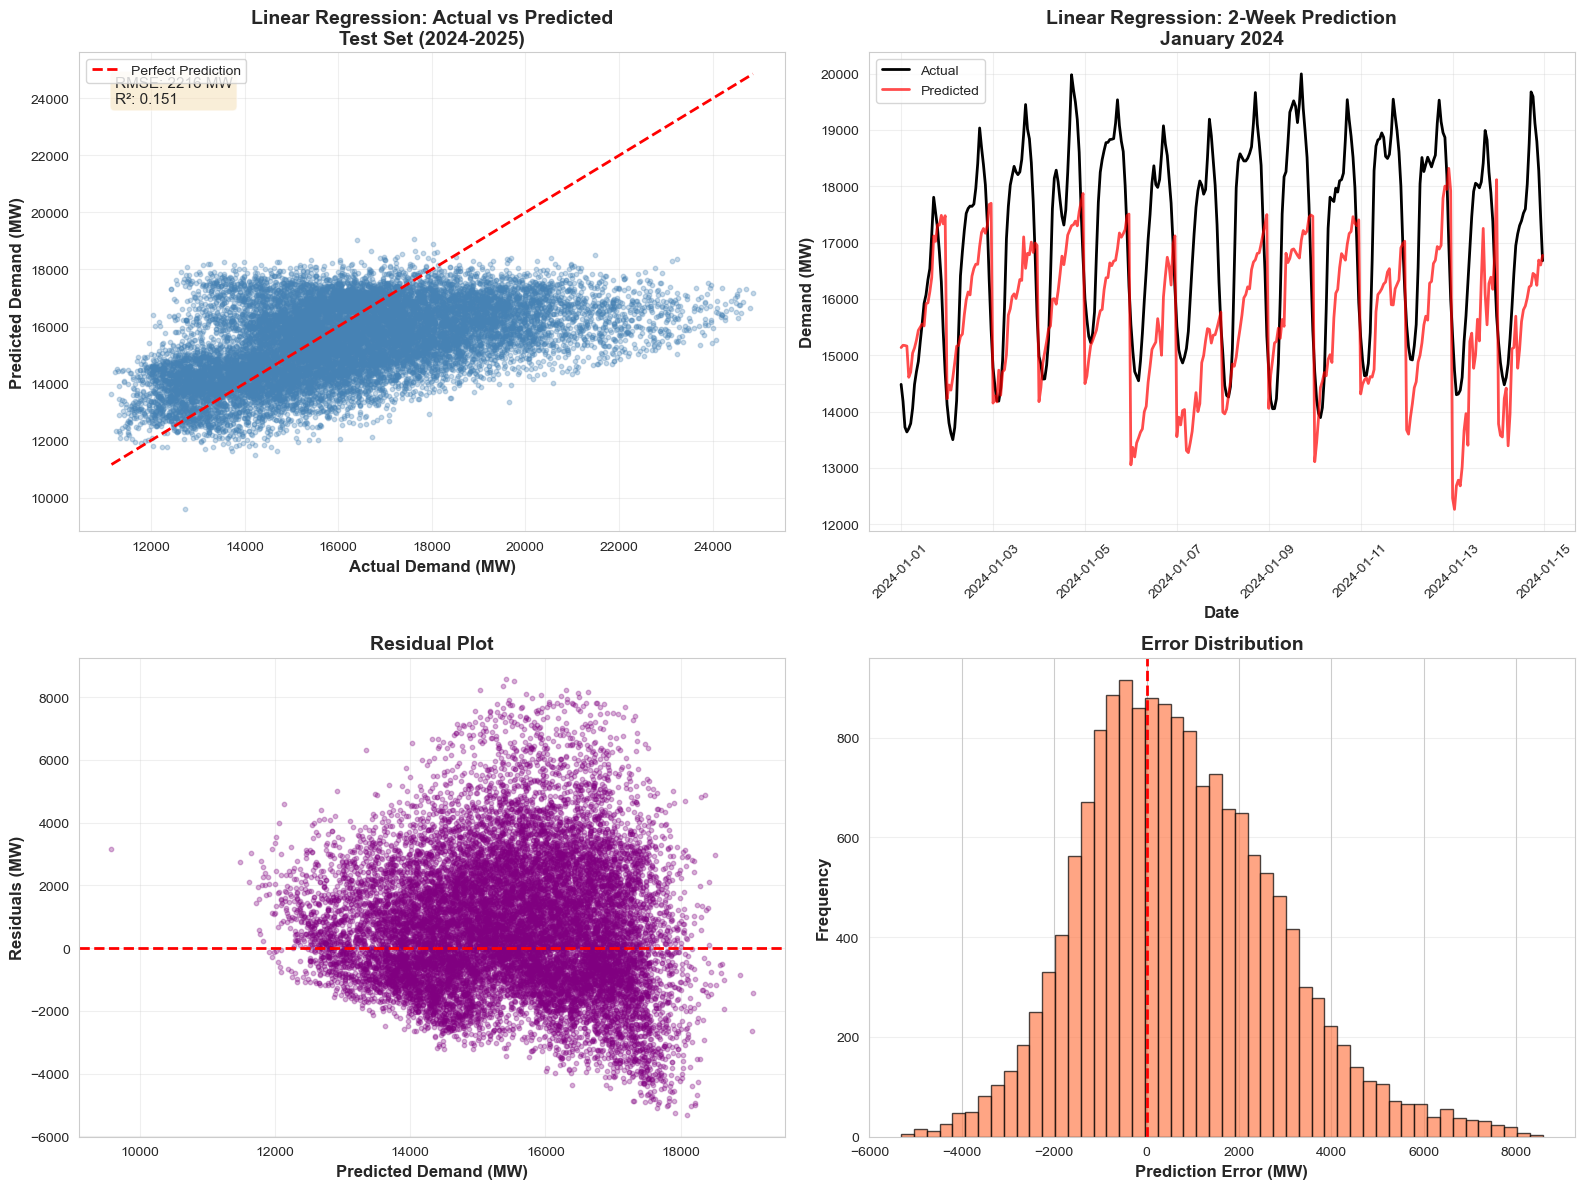

In [12]:
import os

# Correct path to OneDrive folder
presentation_folder = r"C:\Users\nabee\OneDrive - University of Toronto\ECE1513H ML Project\04_Presentation"

# Verify it exists
print(f"Target folder: {presentation_folder}")
print(f"Exists: {os.path.exists(presentation_folder)}")

# From now on, use this path for all saves
# Let's re-save the baseline performance plot to the correct location

# Recreate figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Scatter
ax1 = axes[0, 0]
ax1.scatter(y_test, y_test_pred, alpha=0.3, s=10, color='steelblue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Demand (MW)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Demand (MW)', fontsize=12, fontweight='bold')
ax1.set_title('Linear Regression: Actual vs Predicted\nTest Set (2024-2025)', 
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, f'RMSE: {test_metrics["RMSE"]:.0f} MW\nR²: {test_metrics["R2"]:.3f}', 
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Time series
ax2 = axes[0, 1]
test_df = df[test_mask].copy()
test_df['Predicted'] = y_test_pred
plot_range = slice(0, 336)
ax2.plot(test_df['DateTime'].iloc[plot_range], y_test.iloc[plot_range], 
         label='Actual', linewidth=2, color='black')
ax2.plot(test_df['DateTime'].iloc[plot_range], test_df['Predicted'].iloc[plot_range], 
         label='Predicted', linewidth=2, color='red', alpha=0.7)
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Demand (MW)', fontsize=12, fontweight='bold')
ax2.set_title('Linear Regression: 2-Week Prediction\nJanuary 2024', 
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# Plot 3: Residuals
ax3 = axes[1, 0]
residuals = y_test - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.3, s=10, color='purple')
ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Demand (MW)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Residuals (MW)', fontsize=12, fontweight='bold')
ax3.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Histogram
ax4 = axes[1, 1]
ax4.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax4.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Prediction Error (MW)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax4.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save to OneDrive
save_path = os.path.join(presentation_folder, "baseline_lr_performance.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved to OneDrive: {save_path}")

plt.show()

✓ Saved to OneDrive: C:\Users\nabee\OneDrive - University of Toronto\ECE1513H ML Project\04_Presentation\feature_importance_lr.png


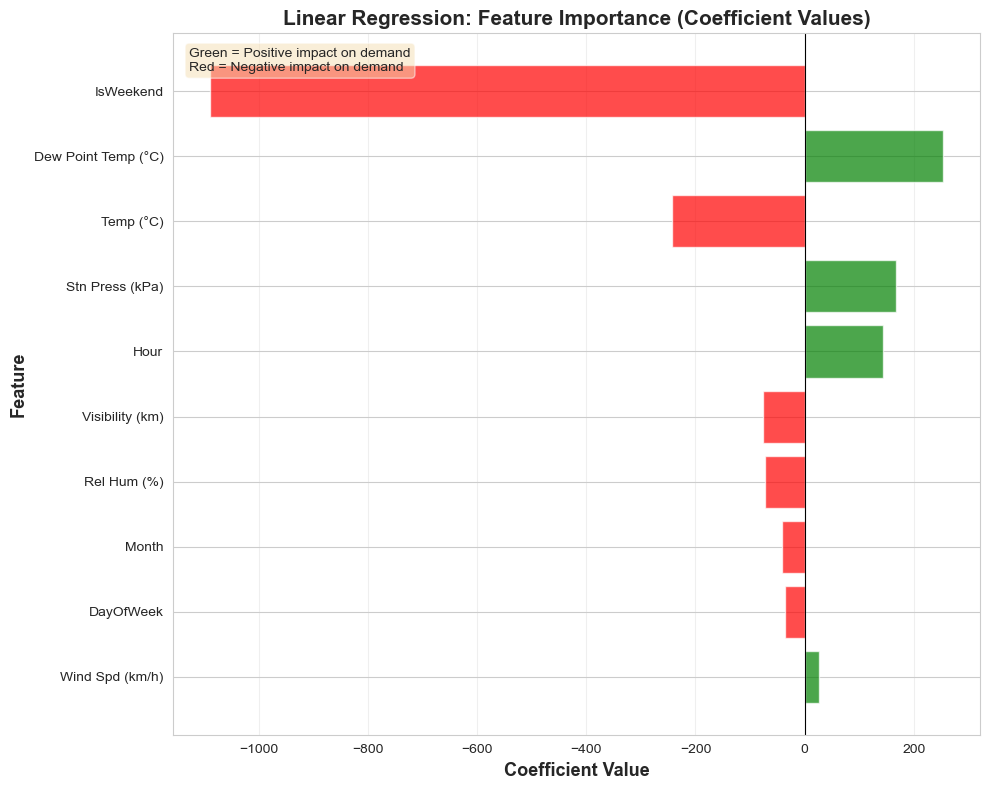


Feature Importance Interpretation:
----------------------------------------------------------------------
IsWeekend           :  -1089.6  → decreases demand
Dew Point Temp (°C) :    254.1  → increases demand
Temp (°C)           :   -243.6  → decreases demand
Stn Press (kPa)     :    168.0  → increases demand
Hour                :    142.8  → increases demand
Visibility (km)     :    -75.5  → decreases demand
Rel Hum (%)         :    -73.4  → decreases demand
Month               :    -42.2  → decreases demand
DayOfWeek           :    -35.3  → decreases demand
Wind Spd (km/h)     :     25.9  → increases demand


In [13]:
# Set OneDrive path
presentation_folder = r"C:\Users\nabee\OneDrive - University of Toronto\ECE1513H ML Project\04_Presentation"

# Get feature coefficients from the model
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_
})

# Sort by absolute value
feature_importance['Abs_Coef'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coef', ascending=True)

# Create horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['red' if x < 0 else 'green' for x in feature_importance['Coefficient']]
ax.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value', fontsize=13, fontweight='bold')
ax.set_ylabel('Feature', fontsize=13, fontweight='bold')
ax.set_title('Linear Regression: Feature Importance (Coefficient Values)', 
             fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add text explanation
textstr = 'Green = Positive impact on demand\nRed = Negative impact on demand'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Save to OneDrive
save_path = os.path.join(presentation_folder, "feature_importance_lr.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved to OneDrive: {save_path}")

plt.show()

# Print interpretation
print("\n" + "="*70)
print("Feature Importance Interpretation:")
print("-"*70)
for _, row in feature_importance.sort_values('Abs_Coef', ascending=False).iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"{row['Feature']:20s}: {row['Coefficient']:8.1f}  → {direction} demand")

In [11]:
import os

# Check the absolute path where we're saving
presentation_folder = "../../../../../ECE1513H ML Project/04_Presentation"
abs_path = os.path.abspath(presentation_folder)

print(f"Saving files to:")
print(abs_path)

print(f"\nDoes this path exist? {os.path.exists(abs_path)}")

# List files in the folder
if os.path.exists(abs_path):
    files = os.listdir(abs_path)
    print(f"\nFiles currently in folder ({len(files)}):")
    for f in files:
        print(f"  - {f}")

Saving files to:
C:\Users\nabee\ECE1513H ML Project\04_Presentation

Does this path exist? True

Files currently in folder (2):
  - baseline_lr_performance.png
  - feature_importance_lr.png


✓ Saved improved heatmap to OneDrive: C:\Users\nabee\OneDrive - University of Toronto\ECE1513H ML Project\04_Presentation\demand_heatmap_hour_month_clean.png


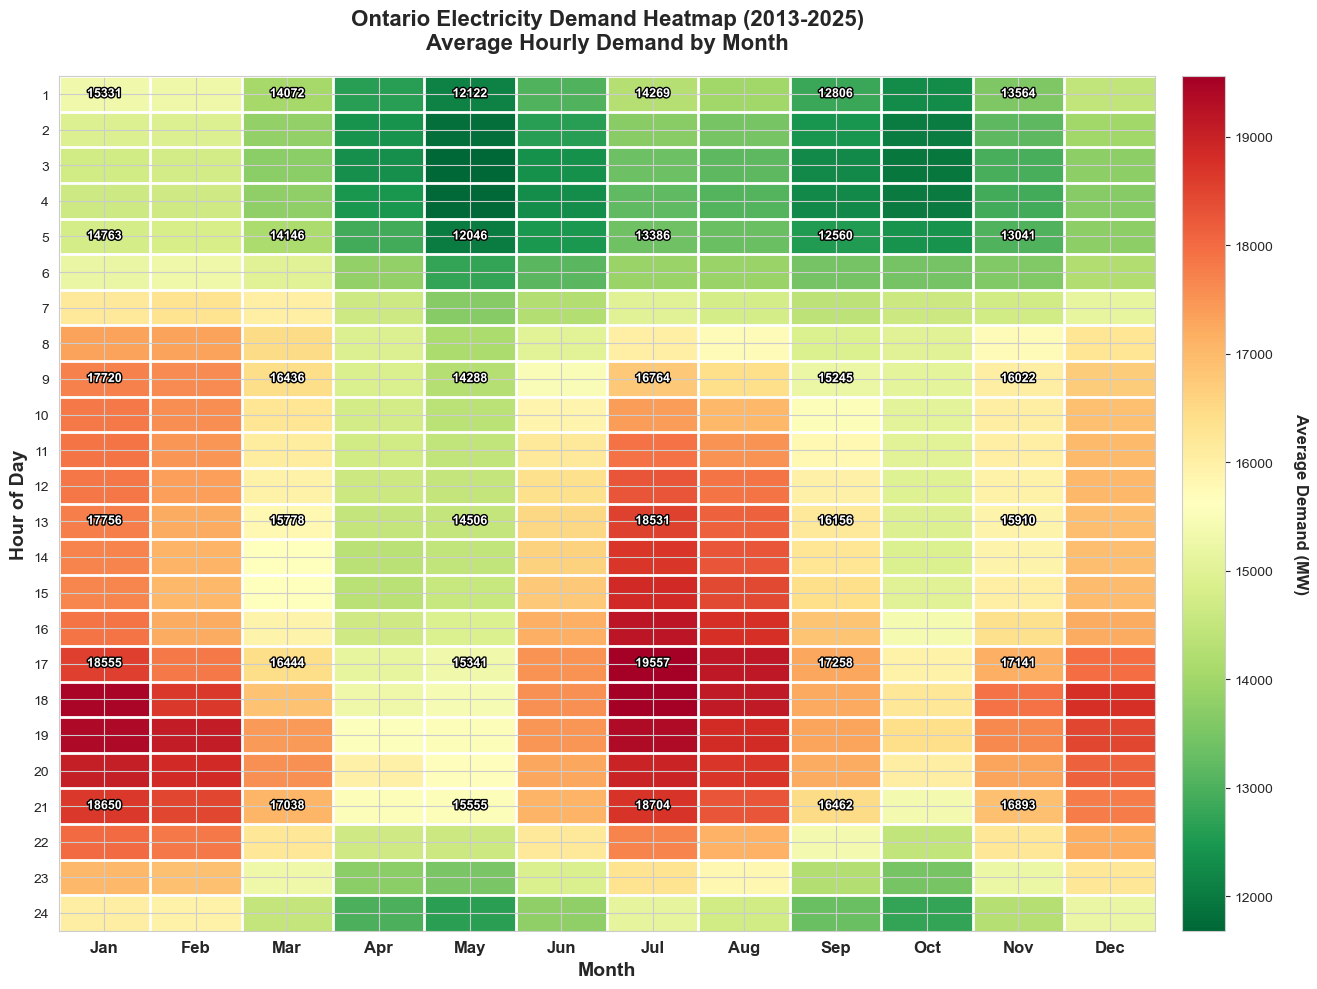


INSIGHTS FOR PRESENTATION:
----------------------------------------------------------------------
✓ Peak demand: 5-7 PM (dinner time, everyone home)
✓ Lowest demand: 3-5 AM (overnight, minimal activity)
✓ Winter > Summer > Fall > Spring (heating needs > cooling needs)
✓ Clear daily cycles across ALL seasons → perfect for time series ML!


In [17]:
import matplotlib.patheffects as path_effects

# Set OneDrive path
presentation_folder = r"C:\Users\nabee\OneDrive - University of Toronto\ECE1513H ML Project\04_Presentation"

# Create pivot table: average demand by hour and month
heatmap_data = df.groupby(['Month', 'Hour'])['Ontario Demand'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='Hour', columns='Month', values='Ontario Demand')

# Create the heatmap
fig, ax = plt.subplots(figsize=(14, 10))

# Plot heatmap with better color scheme
im = ax.imshow(heatmap_pivot, cmap='RdYlGn_r', aspect='auto', interpolation='nearest')

# Set ticks and labels
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=12, fontweight='bold')
ax.set_yticks(range(24))
ax.set_yticklabels(range(1, 25), fontsize=10)

ax.set_xlabel('Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Hour of Day', fontsize=14, fontweight='bold')
ax.set_title('Ontario Electricity Demand Heatmap (2013-2025)\nAverage Hourly Demand by Month', 
             fontsize=16, fontweight='bold', pad=20)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Average Demand (MW)', rotation=270, labelpad=25, fontsize=12, fontweight='bold')

# Add grid for readability
ax.set_xticks(np.arange(12) - 0.5, minor=True)
ax.set_yticks(np.arange(24) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)

# Add white text with black outline (every 4th hour, every 2nd month)
for i in range(0, 24, 4):
    for j in range(0, 12, 2):
        value = heatmap_pivot.iloc[i, j]
        text = ax.text(j, i, f'{value:.0f}',
                      ha="center", va="center", color="white", fontsize=9, 
                      fontweight='bold')
        text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black')])

plt.tight_layout()

# Save to OneDrive
save_path = os.path.join(presentation_folder, "demand_heatmap_hour_month_clean.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved improved heatmap to OneDrive: {save_path}")

plt.show()

print("\n" + "="*70)
print("INSIGHTS FOR PRESENTATION:")
print("-"*70)
print("✓ Peak demand: 5-7 PM (dinner time, everyone home)")
print("✓ Lowest demand: 3-5 AM (overnight, minimal activity)")
print("✓ Winter > Summer > Fall > Spring (heating needs > cooling needs)")
print("✓ Clear daily cycles across ALL seasons → perfect for time series ML!")